# Evoscope Teaching Notebook

This notebook uses the modular version of Evoscope to show how local regulatory rules generate multicellular spatial patterns.

# Part I — Exploring the Evoscope simulation

## 1. Import the model

The key teaching objects are `Config`, `Evoscope`, and `grid_to_numpy`.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from evoscope import Config, Evoscope, grid_to_numpy
from evoscope.visualization import plot_grid_array, plot_genes, plot_clusters
from evoscope.io import save_global_gene_csv, save_cluster_gene_csv

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import ListedColormap, BoundaryNorm
from IPython.display import HTML

In [2]:
import evoscope
print(evoscope.__file__)

/home/lunan/Evoscope/evoscope_teaching_modules/evoscope_teaching/evoscope/__init__.py


## 2. Define a minimal world

Students can change these parameters and immediately observe how the simulation changes.

In [3]:
cfg = Config(
    width=60,
    height=40,
    initial_cells=30,
    initial_medium_nutrient=6.9,
    #diffusion_rate=.5,
    #h_bias_strength=5,
    seed=42,
    verbose=False,
)


#sim = Evoscope(cfg)
#print(sim.summary_line())

## 3. Run the simulation

Each step updates sensing, regulation, energy, cell cycle, commitment, movement, division, attack/division, nutrient diffusion, and metrics.

In [8]:
sim = Evoscope(cfg)

frames = []

for _ in range(120):
    sim.step()
    frames.append(grid_to_numpy(sim).copy())


# Values:
# -1 = empty
#  0 = undetermined
#  1-8 = committed clusters 0-7

colors = [
    "black",      # -1 empty
    "lightgray",  #  0 undetermined
    "red",        #  1 cluster 0
    "green",      #  2 cluster 1
    "gold",       #  3 cluster 2
    "blue",       #  4 cluster 3
    "magenta",    #  5 cluster 4
    "cyan",       #  6 cluster 5
    "white",      #  7 cluster 6
    "orange",     #  8 cluster 7
]

cmap = ListedColormap(colors)

bounds = [-1.5, -0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(15, 6))

im = ax.imshow(
    frames[0],
    cmap=cmap,
    norm=norm,
    interpolation="nearest",
)

ax.axis("off")

def update(i):
    im.set_data(frames[i])
    ax.set_title(f"Evoscope - epoch {i + 1}")
    return [im]

anim = FuncAnimation(
    fig,
    update,
    frames=len(frames),
    interval=100,
    blit=True,
)

import matplotlib.patches as mpatches

legend_items = [
    mpatches.Patch(color="black", label="empty"),
    mpatches.Patch(color="lightgray", label="undetermined"),
    mpatches.Patch(color="red", label="cluster 0"),
    mpatches.Patch(color="green", label="cluster 1"),
    mpatches.Patch(color="gold", label="cluster 2"),
    mpatches.Patch(color="blue", label="cluster 3"),
    mpatches.Patch(color="magenta", label="cluster 4"),
    mpatches.Patch(color="cyan", label="cluster 5"),
    mpatches.Patch(color="white", label="cluster 6"),
    mpatches.Patch(color="orange", label="cluster 7"),
]

ax.legend(
    handles=legend_items,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    borderaxespad=0,
)

plt.close(fig)

HTML(anim.to_jshtml())

## 4. Plot global regulatory dynamics

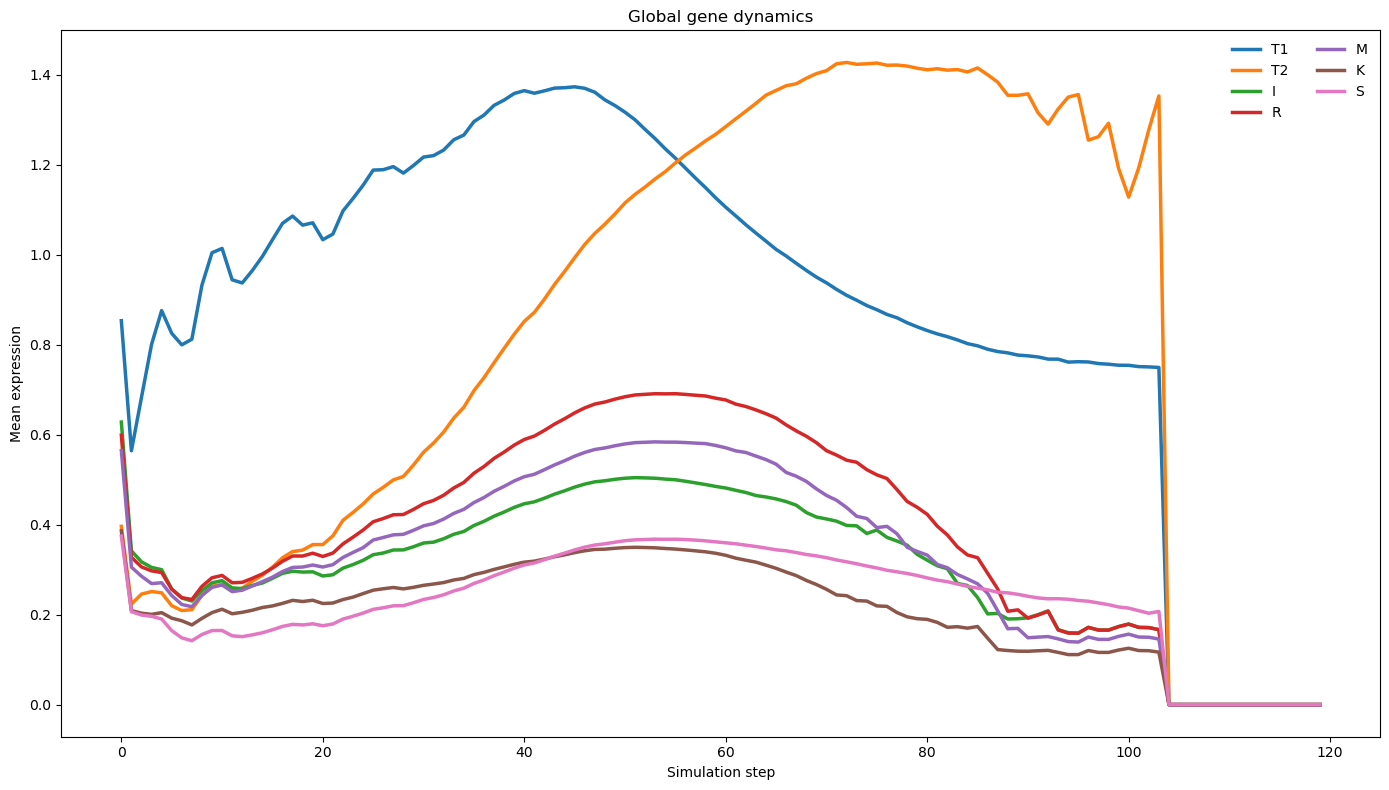

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'Global gene dynamics'}, xlabel='Simulation step', ylabel='Mean expression'>)

In [5]:
plot_genes(sim)

## 5. Plot one gene by cluster

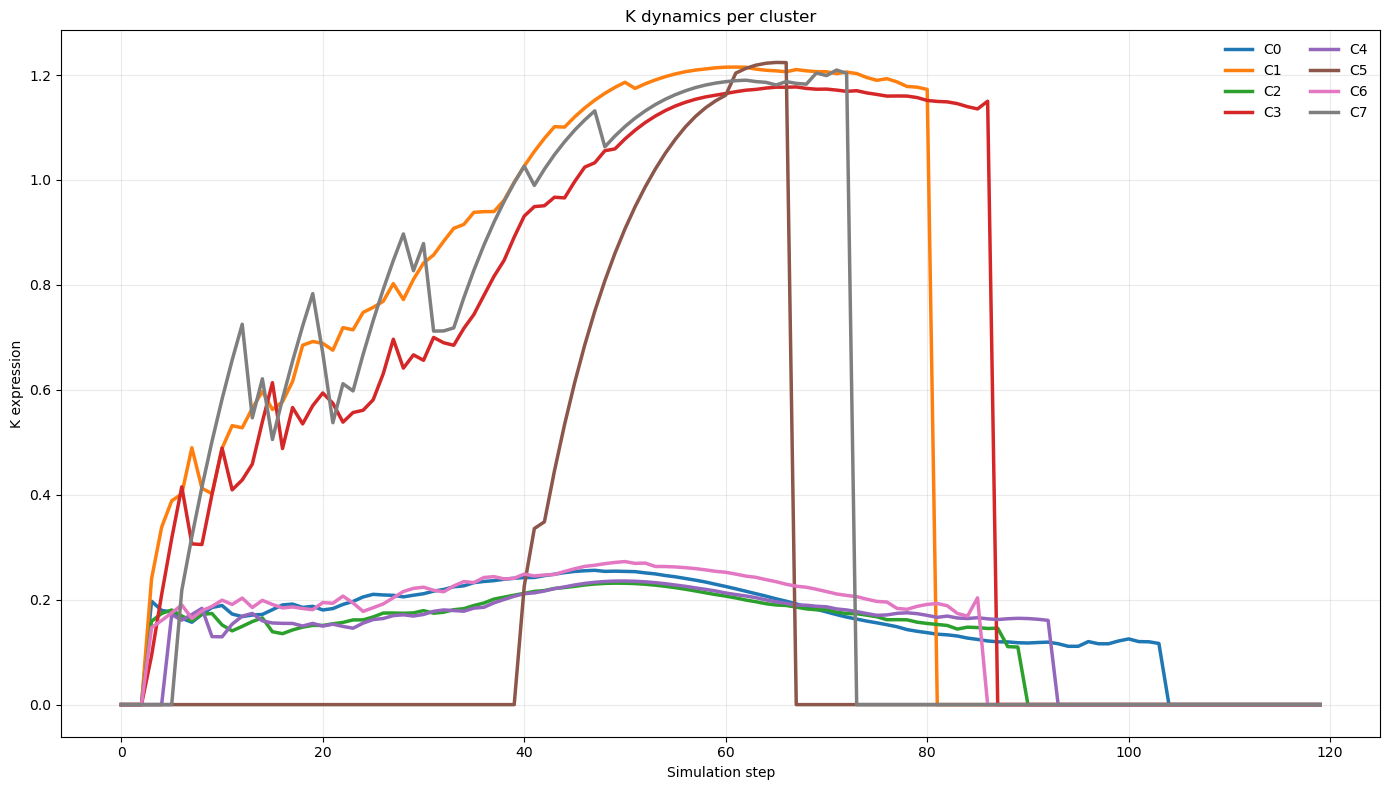

(<Figure size 1400x800 with 1 Axes>,
 <Axes: title={'center': 'K dynamics per cluster'}, xlabel='Simulation step', ylabel='K expression'>)

In [6]:
plot_clusters(sim, gene="K")

## 6. Export gene-dynamics files

The autoencoder analysis uses two gene-dynamics tables generated from the simulation:

- `global_genes.csv`: average regulatory/protein dynamics across all living cells.
- `cluster_genes.csv`: cluster-specific regulatory/protein dynamics for the eight commitment states.

These files are aligned with the morphology snapshots saved during the simulation and are later used as observable targets for the autoencoder and latent-space correlation analyses.

In [7]:
save_global_gene_csv(sim, path="global_genes.csv")
save_cluster_gene_csv(sim, path="cluster_genes.csv")

## 7. Exercises

1. Increase `initial_medium_nutrient`. Does the final morphology become denser?
2. Increase `diffusion_rate`. Does nutrient smoothing reduce local heterogeneity?
3. Increase `h_bias_strength`. Do committed clusters become more behaviorally distinct?
4. Change `seed`. Which patterns are robust and which are stochastic?


# Part II — From morphology to latent variables

The following section assumes that the simulation has generated:
- morphology snapshots in `snapshots/`
- global regulatory dynamics in `global_genes.csv`
- cluster-level regulatory dynamics in `cluster_genes.csv`

These outputs will now be used to train autoencoders and correlate latent morphological variables with regulatory dynamics.

## 8. Autoencoder analysis (Global)

In [5]:
from evoscope.datasets import TorexDataset
from evoscope.autoencoder import train_autoencoder
from evoscope.latent import export_latents, export_predictions
from evoscope.correlations import compute_latent_metric_correlations, plot_correlation_heatmap
from evoscope.analysis_plots import plot_attractor_summary

In [7]:
dataset_global = TorexDataset(
    snapshots_dir="snapshots",
    target_mode="global",
    global_csv="global_genes.csv",
)

model_global, history_global = train_autoencoder(
    dataset_global,
    latent_dim=8,
    epochs=100,
    batch_size=16,
    outdir="ae_outputs_global",
)

epoch 001 | train loss 2.6848 (recon 2.2930, gene 0.3918) | val loss 2.4893 (recon 2.2687, gene 0.2207)
epoch 002 | train loss 2.6157 (recon 2.2675, gene 0.3481) | val loss 2.3341 (recon 2.1817, gene 0.1524)
epoch 003 | train loss 2.4085 (recon 2.1771, gene 0.2313) | val loss 1.8964 (recon 1.7392, gene 0.1572)
epoch 004 | train loss 1.9354 (recon 1.7618, gene 0.1736) | val loss 1.4993 (recon 1.0697, gene 0.4295)
epoch 005 | train loss 1.5421 (recon 1.2951, gene 0.2470) | val loss 0.9957 (recon 0.8607, gene 0.1350)
epoch 006 | train loss 1.2331 (recon 1.1342, gene 0.0988) | val loss 0.8043 (recon 0.7058, gene 0.0986)
epoch 007 | train loss 1.1290 (recon 1.0118, gene 0.1172) | val loss 0.7035 (recon 0.6050, gene 0.0985)
epoch 008 | train loss 1.1057 (recon 0.9706, gene 0.1351) | val loss 0.6927 (recon 0.5889, gene 0.1038)
epoch 009 | train loss 1.0697 (recon 0.9175, gene 0.1522) | val loss 0.7356 (recon 0.6273, gene 0.1084)
epoch 010 | train loss 1.0604 (recon 0.9019, gene 0.1585) | val 

## 9. Latent-gene correlation (Global)

(<Figure size 1000x480 with 2 Axes>,
 <Axes: title={'center': 'Global latent variables × gene dynamics'}>)

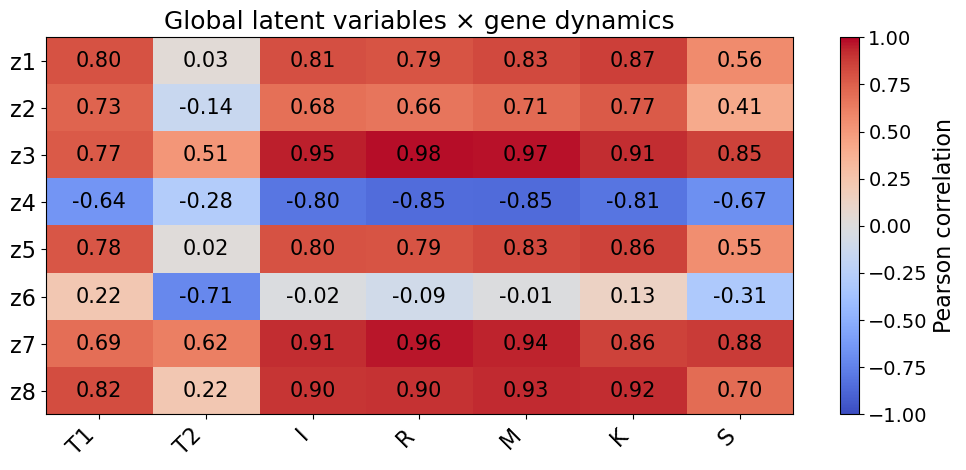

In [8]:
corr_global = compute_latent_metric_correlations(
    latents="ae_outputs_global/latents.csv",
    metrics="global_genes.csv",
)

plot_correlation_heatmap(
    corr_global,
    outfile="global_latent_gene_heatmap.png",
    title="Global latent variables × gene dynamics",
)

## 10. Autoencoder analysis (Cluster)

In [9]:
dataset_cluster = TorexDataset(
    snapshots_dir="snapshots",
    target_mode="cluster_flat",
    cluster_csv="cluster_genes.csv",
)

model_cluster, history_cluster = train_autoencoder(
    dataset_cluster,
    latent_dim=8,
    epochs=100,
    batch_size=16,
    outdir="ae_outputs_cluster",
)

epoch 001 | train loss 2.7442 (recon 2.2933, gene 0.4509) | val loss 2.4419 (recon 2.2693, gene 0.1726)
epoch 002 | train loss 2.6992 (recon 2.2688, gene 0.4304) | val loss 2.3538 (recon 2.1913, gene 0.1624)
epoch 003 | train loss 2.5791 (recon 2.1823, gene 0.3968) | val loss 2.0108 (recon 1.8131, gene 0.1976)
epoch 004 | train loss 2.1669 (recon 1.8088, gene 0.3582) | val loss 1.6317 (recon 1.0225, gene 0.6093)
epoch 005 | train loss 1.7907 (recon 1.2730, gene 0.5177) | val loss 1.0517 (recon 0.8046, gene 0.2471)
epoch 006 | train loss 1.3957 (recon 1.1134, gene 0.2824) | val loss 0.8440 (recon 0.6990, gene 0.1450)
epoch 007 | train loss 1.2559 (recon 0.9928, gene 0.2631) | val loss 0.7436 (recon 0.6098, gene 0.1339)
epoch 008 | train loss 1.2088 (recon 0.9443, gene 0.2644) | val loss 0.7135 (recon 0.5819, gene 0.1316)
epoch 009 | train loss 1.1888 (recon 0.9278, gene 0.2610) | val loss 0.7033 (recon 0.5725, gene 0.1308)
epoch 010 | train loss 1.1545 (recon 0.8968, gene 0.2577) | val 

## 11. Latent-gene correlation (cluster)

(<Figure size 1000x480 with 2 Axes>,
 <Axes: title={'center': 'Cluster latent variables × gene dynamics'}>)

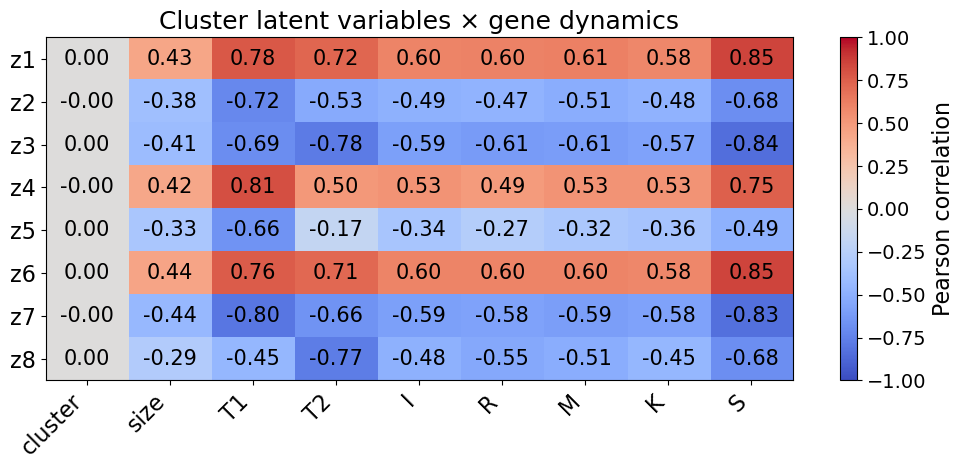

In [10]:
corr_cluster = compute_latent_metric_correlations(
    latents="ae_outputs_cluster/latents.csv",
    metrics="cluster_genes.csv",
)

plot_correlation_heatmap(
    corr_cluster,
    outfile="cluster_latent_gene_heatmap.png",
    title="Cluster latent variables × gene dynamics",
)

## 12. Latent attractor trajectories

(<Figure size 1400x1000 with 4 Axes>,
 array([[<Axes: title={'center': 'A Global latent trajectories'}, xlabel='Step', ylabel='Latent value'>,
         <Axes: title={'center': 'B Cluster latent trajectories'}, xlabel='Step', ylabel='Latent value'>],
        [<Axes: title={'center': 'C Global latent phase portrait (z1,z2)'}, xlabel='z1', ylabel='z2'>,
         <Axes: title={'center': 'D Cluster latent phase portrait (z1,z2)'}, xlabel='z1', ylabel='z2'>]],
       dtype=object))

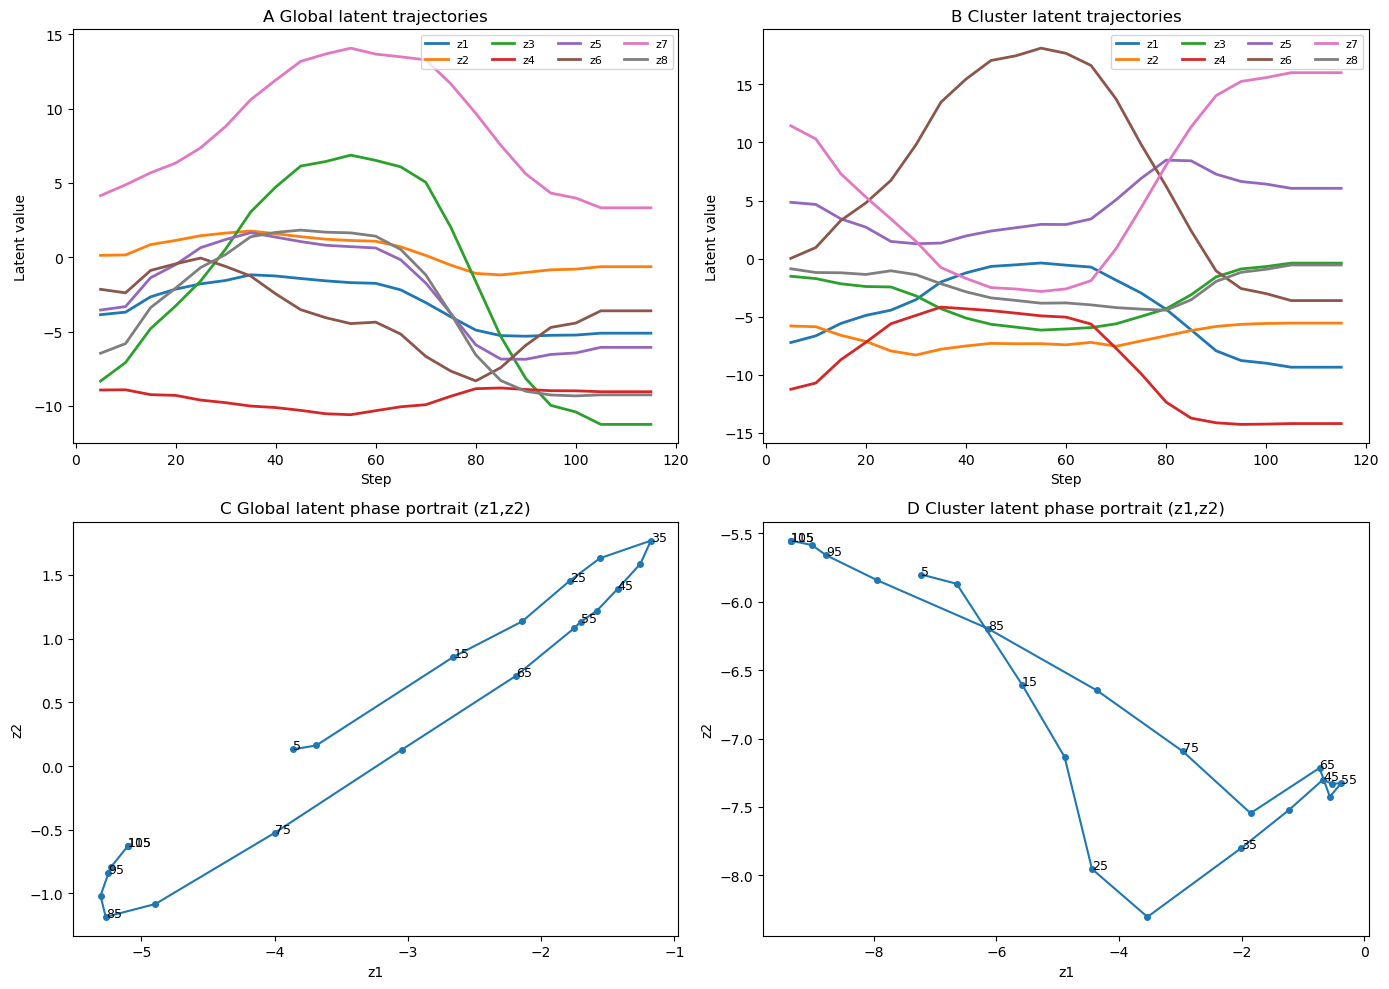

In [11]:
plot_attractor_summary(
    global_latents="ae_outputs_global/latents.csv",
    cluster_latents="ae_outputs_cluster/latents.csv",
    outfile="Figure4_attractors.png",
)